# Dimensionality Reduction

## Install required libraries

In [ ]:
%pip install pandas seaborn scanpy numpy scikit-misc matplotlib

## Load imports

In [2]:
import pandas as pd
import seaborn as sns
import os
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

## Load the preprocessed data

In [3]:
folder_path = '../data/pbmc3k_preprocessed.h5ad'
if not os.path.exists(folder_path):
    print('whoops. double-check path to preprocessed data.')
adata = sc.read_h5ad(folder_path) #returns AnnData type
# checking to see that things are as expected
print('adata: ', adata)

adata:  AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'total_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    layers: 'counts', 'scaled'


## Principal Component Analysis
PCA creates a new set of uncorrelated (orthogonal) variables, called principal components (PCs). The PCs are **linear** combinations of features in the original dataset.

We will be using scanpy's wrapper function sc.pp.pca(). Because our dataset is on the smaller side and it is already scaled (adata.layers['scaled']) (it is now dense), we will use the default zero_center = True which means (to this reader's understanding) scikit learn's pca function will be used. 

The explained variance ration provides us the % of total variance captured by a given component. This will help us choose the number of components to consider. 

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'total_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'scaled'


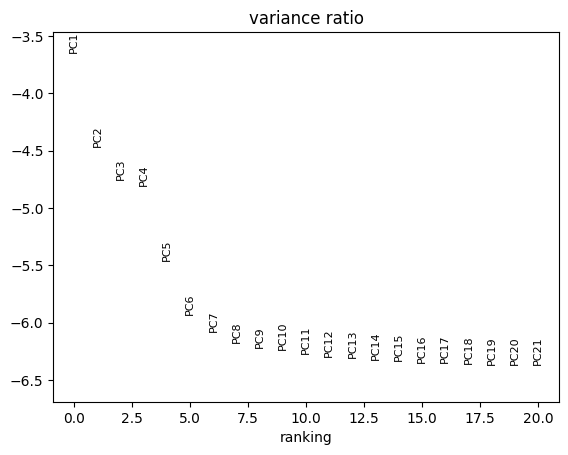

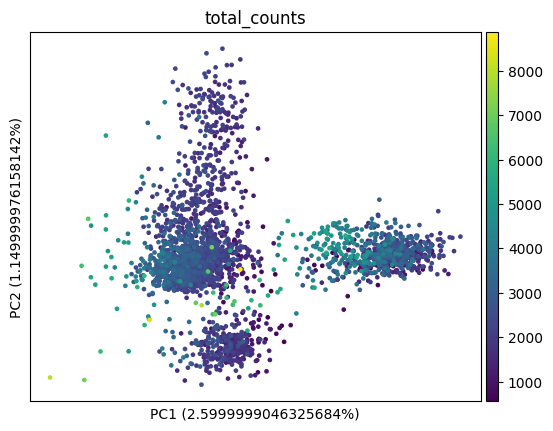

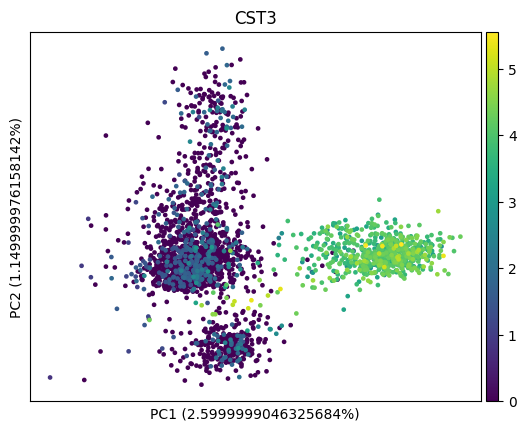

In [4]:
sc.pp.pca(adata,layer = 'scaled', svd_solver='arpack') # this will give 50 pcs total
print(adata)
# Visualizing Explained Variance Ratio (Elbow Plot)
sc.pl.pca_variance_ratio(adata, n_pcs=20, log = True)
sc.pl.pca(adata,color='total_counts',annotate_var_explained=True) # practice for troubleshooting data quality
sc.pl.pca(adata,annotate_var_explained=True,color='CST3')


### Observing the effects of preprocessing on PCA for fun
One thing to look for in a pca plot colored by total_counts would be if the variation being captured by PCA is actually just sequencing depth rather than biology. Another would be if the counts color is still heavily skewed toward one side of the plot after normalization and regressing out technical effects as this may be an indication that the technical noise has not fully been removed. Our process in 01_preprocessing_and_visualization.ipynb, 1) normalize and log-transform, 2) regress out technical variation, and 3) scaling should help with these. 

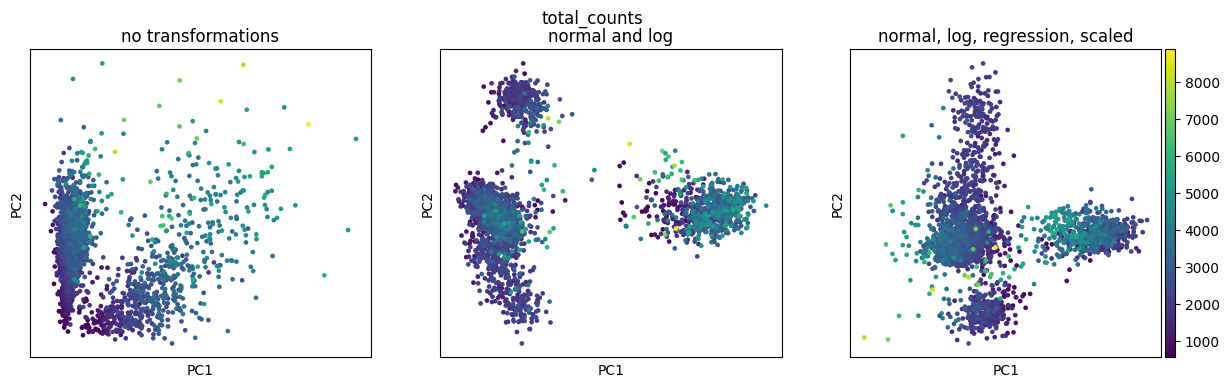

In [5]:
temp_adata = adata.copy()
sc.pp.pca(temp_adata, layer='counts', svd_solver='arpack') # layer = 'counts' => no transformations applied
fig, axs = plt.subplots(1,3,figsize = (15,4))
sc.pl.pca(temp_adata,color='total_counts', ax = axs[0], title='no transformations', show = False, colorbar_loc=None)
sc.pp.pca(temp_adata,svd_solver='arpack') # layer = None => using adata.X normalization and log-transformed (over-writting calculations above for temp_adata)
sc.pl.pca(temp_adata,color='total_counts',ax = axs[1], title = 'normal and log',show = False, colorbar_loc=None)
sc.pl.pca(adata,color='total_counts', ax = axs[2], title='normal, log, regression, scaled', show = False) #, components=['1,2']
plt.suptitle('total_counts')
plt.show()

## t-SNE
t-SNE (t-distributed Stochastic Neighbor Embedding) is a graph based, **non-linear** dimensionality reduction techniqe which projects the high dimensional data onto 2D or 3D components. The method defines a Gaussian probability distribution based on the high dimensional Euclidean distances between data points.

While not a part of the 3k PBMCs legacy workflow, we still include it here as scRNA-seq datasets are rather sparse due to dropout events (missing value is likely a technical artifact) and therefore highly non-linear, visualization with the linear dimensionality reduction technique PCA is not very appropriate. According to Single-Cell Analysis Best Practices, PCA is typically used to selct the top 10-50 PCs which are used for downstream analysis tasks (such as this one). 

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'total_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', 'tsne'
    obsm: 'X_pca', 'X_tsne'
    varm: 'PCs'
    layers: 'counts', 'scaled'


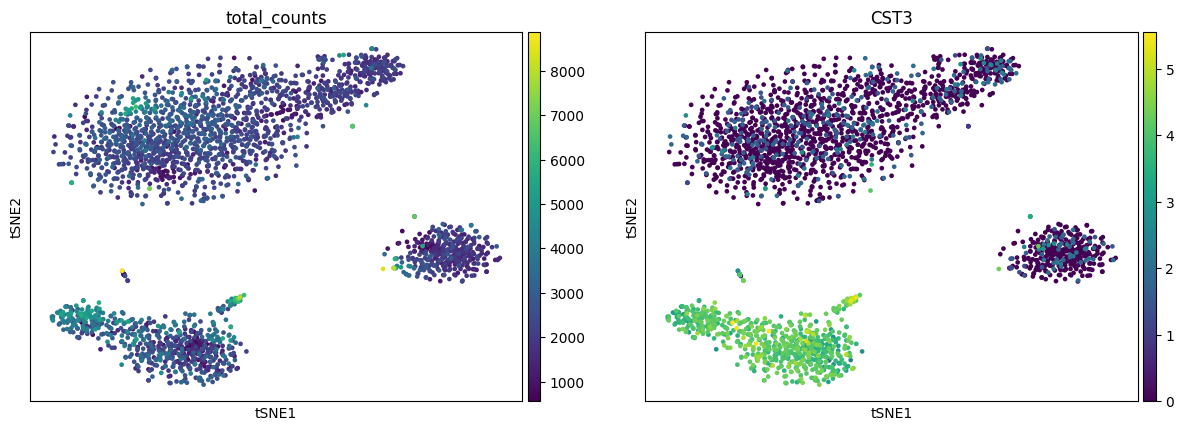

In [7]:
sc.tl.tsne(adata,use_rep='X_pca')
print(adata)
sc.pl.tsne(adata, color = ['total_counts', 'CST3'])

## UMAP
UMAP (Uniform Manifold Approximation and Projection) is also a graph based, **non-linear** dimensionality reduction technique and principally similar to t-SNE. It constructs a high dimensional graph representation of the dataset and optimizes the low dimensional graph representation to be structurally as similar as possible to the original graph. 

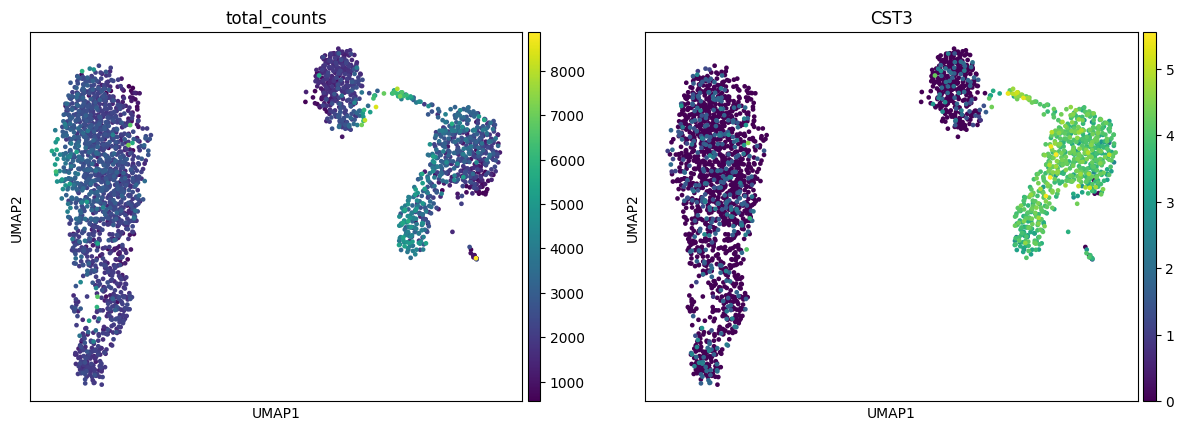

The results here seem to mirror the results produced in the scanpy tutorial being followed.
After reading "Uniform manifold approximation and projection," a nature reviews methods primer, this is okay.
Accoring to the article, any rotation or reflection of the representation is equally suitable since the exact low dimensional representation has no fixed or meaningful directions.


In [ ]:
#need to find neighbors for umap
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40) # n_neighbors = 15, X_pca (n_pcs = 50) is used by default.
sc.tl.umap(adata)
sc.pl.umap(adata, color=['total_counts', 'CST3'])
print('The results here seem to mirror the results produced in the scanpy tutorial being followed.')
print('After reading "Uniform manifold approximation and projection," a nature reviews methods primer, this is okay.')
print('According to the article, any rotation or reflection of the representation is equally suitable since the exact low dimensional representation has no fixed or meaningful directions.')

## Saving reduced dataset

In [10]:
pca_data = '../data/pbmc3k_pca.h5ad'
adata.write(pca_data, compression='gzip')
# verifying
if os.path.exists(pca_data):
    print('Pca data saved successfully.')
else:
    print('pca to save preprocessed data.')

Pca data saved successfully.
